<a href="https://colab.research.google.com/github/SAYildirim/dnn-comms/blob/main/demodulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import numpy as np
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CyclicLR
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from scipy.special import erfc

# ---------- Parameters ----------
mod_type = 'qam'
M = int(16)                 # modulation order
n_symbols = int(1e6)        # total symbols to generate
train_frac = 0.85           # fraction for training
valid_frac = 0.05           # fraction for validation
snr_db_train = 20.0         # training SNR in dB (Eb/N0-like)
snr_db_test = np.arange(start=-4,stop=12, step = 2) # range of testing SNR in dB
batch_size = 64
n_epochs = 300
lr = 1e-3                   # learning rate
patience = 20
delta = 1e-6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [86]:
# ---------- Helper functions ----------
def modulate(symbols,mod_type=None,M=0):
    if mod_type==None:
        raise ValueError('Invalid value for mod_type')
    if (M<2) or ((M & (M -1))!=0): #if M not a power of 2
        raise ValueError('M should be a power of 2')
    func_dict = {'psk': psk_modulation,'qam':qam_modulation}
    return func_dict[mod_type.lower()](symbols, M) #call appropriate function

def psk_modulation(symbols, M):
    # M-PSK constellation generation
    m = np.arange(0,M) #all information symbols m={0,1,...,M-1}
    I = 1/np.sqrt(2)*np.cos(m/M*2*np.pi)
    Q = 1/np.sqrt(2)*np.sin(m/M*2*np.pi)
    constellation = I + 1j*Q #reference constellation
    return constellation[symbols]

def qam_modulation(symbols, M):
    # M-QAM constellation generation
    if (M==1) or (np.mod(np.log2(M),2)!=0): # M not a even power of 2
      raise ValueError('Only square MQAM supported. M must be even power of 2')

    n = np.arange(0,M) # Sequential address from 0 to M-1 (1xM dimension)
    a = np.asarray([x^(x>>1) for x in n]) # Binary code to Gray code
    D = np.sqrt(M).astype(int) #Dimension of K-Map - N x N matrix
    a = np.reshape(a,(D,D)) # NxN gray coded matrix
    oddRows=np.arange(start = 1, stop = D ,step=2) # identify alternate rows
    a[oddRows,:] = np.fliplr(a[oddRows,:]) #Flip rows - KMap representation
    nGray=np.reshape(a,(M)) # reshape to 1xM - Gray code walk on KMap
    #Construction of ideal M-QAM constellation from sqrt(M)-PAM
    (x,y)=np.divmod(nGray,D) #element-wise quotient and remainder
    Ax=2*x+1-D # PAM Amplitudes 2d+1-D - real axis
    Ay=2*y+1-D # PAM Amplitudes 2d+1-D - imag axis
    constellation = Ax+1j*Ay
    return constellation[symbols]

def psk_bitmap(symbols, M):
    Exp = (2**np.arange(np.log2(M))).astype(int)
    return ((symbols.astype(int).reshape(-1,1) & Exp)!=0).astype(int)[:, ::-1]

def psk_intmap(bits):
    b2i = 2**np.arange(bits.shape[0]-1, -1, -1)
    return (bits*b2i).sum(axis=1)

def bpsk_map(bits):
    # Map bits {0,1} -> symbols {-1,+1}
    return 2 * bits - 1

def awgn_iq(symbols_iq, snr_db):
    # symbols_iq: shape (N, 2) real (I,Q)
    # compute noise std from SNR (assuming symbol power = mean(|s|^2))
    ps = np.mean(np.sum(symbols_iq**2, axis=1))
    snr_linear = 10 ** (snr_db / 10.0)
    sigma = ps / snr_linear
    N0 = sigma / 2 # per-dimension (I and Q) variance
    noise = np.sqrt(N0/2) * np.random.randn(*symbols_iq.shape)
    return symbols_iq + noise

def ser_awgn(EbN0dBs,mod_type=None,M=0,coherence=None):
    if mod_type==None:
        raise ValueError('Invalid value for mod_type')
    if (M<2) or ((M & (M -1))!=0): #if M not a power of 2
        raise ValueError('M should be a power of 2')
    func_dict = {'psk': psk_awgn,'qam':qam_awgn}
    gamma_s = np.log2(M)*(10**(EbN0dBs/10))
    if mod_type.lower()=='fsk': #call appropriate function
        return func_dict[mod_type.lower()](M,gamma_s,coherence)
    else:
        return func_dict[mod_type.lower()](M,gamma_s) #call appropriate function

def psk_awgn(M,gamma_s):
    gamma_b = gamma_s/np.log2(M)
    if (M==2):
        SERs = 0.5*erfc(np.sqrt(2*gamma_b))
    elif M==4:
        Q = 0.5*erfc(np.sqrt(gamma_b))
        SERs = 2*Q-Q**2
    else:
        SERs = erfc(np.sqrt(gamma_s)*np.sin(np.pi/M))
    return SERs

def qam_awgn(M,gamma_s):
    if (M==1) or (np.mod(np.log2(M),2)!=0): # M not a even power of 2
        raise ValueError('Only square MQAM supported. M must be even power of 2')
    SERs = 1-(1-(1-1/np.sqrt(M))*erfc(np.sqrt(3/2*gamma_s/(M-1))))**2
    return SERs

# ---------- Single-layer model ----------
class SingleLayerDemod(nn.Module):
    def __init__(self, M):
        super().__init__()
        # Input  2 -> in-phase and quadrature components
        # Output M -> M logits -> softmax gives probability of symbols
        self.M = M
        self.linear = nn.Linear(2, self.M, bias=True)

    def forward(self, x):
        # x shape: (batch, 2)
        out = self.linear(x)  # (batch,2)
        prob = torch.softmax(out, dim=1)
        return prob

# Custom EarlyStopping class from scratch
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, path='checkpoint.pt', verbose=True):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            # Save checkpoint if improvement observed
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Model improved; checkpoint saved at loss {val_loss:.6f}")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Early stopping triggered.")

In [87]:
# ---------- Generate dataset ----------
## Random bits
#bits = np.random.randint(0, 2, size=(n_symbols,)).astype(np.float32)
## Map to BPSK symbols on I axis; Q = 0
#symbols = bpsk_map(bits)  # shape (n_symbols,)
#symbols_iq = np.stack([symbols, np.zeros_like(symbols)], axis=1)  # (N,2)

# Random symbols
symbols = np.random.randint(0, M, size=(n_symbols,)).astype(int)
modulated_symbols = modulate(symbols,mod_type,M)
symbols_iq = np.stack([np.real(modulated_symbols),
                       np.imag(modulated_symbols)], axis=1)  # (N,2)
bits    = psk_bitmap(symbols, M)

# Split train/test
n_train = int(n_symbols * train_frac)
n_valid = int(n_symbols * valid_frac)
n_test  = n_symbols - n_train - n_valid

train_x = awgn_iq(symbols_iq[:n_train], snr_db_train)
train_y = symbols[:n_train]
# re-noise validation partition (fresh noise)
valid_x = awgn_iq(symbols_iq[n_train:n_train+n_valid], 3)
valid_y = symbols[n_train:n_train+n_valid]

# Convert to PyTorch tensors
train_x_t = torch.from_numpy(train_x).float()
train_y_t = torch.from_numpy(train_y).float().long()  # shape (N,1)
valid_x_t = torch.from_numpy(valid_x).float()
valid_y_t = torch.from_numpy(valid_y).float().long()

train_ds = TensorDataset(train_x_t, train_y_t)
valid_ds = TensorDataset(valid_x_t, valid_y_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

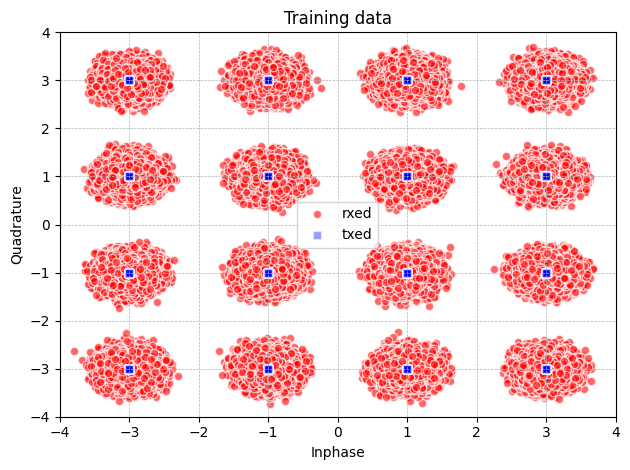

In [88]:
fig, ax = plt.subplots()
I, Q = symbols_iq[:n_train][:,0], symbols_iq[:n_train][:,1]
ax.scatter(train_x[:,0], train_x[:,1], c='red', label='rxed', alpha=0.6,
           edgecolor='white')
ax.scatter(I, Q, c='blue',marker='s',label='txed',alpha=0.4,edgecolor='white')
ax_lim = np.ceil(1.1*np.max([I, Q]))
plt.ylim(-ax_lim, ax_lim)
plt.xlim(-ax_lim, ax_lim)
plt.title('Training data')
plt.xlabel('Inphase')
plt.ylabel('Quadrature')
plt.legend(loc="center")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [89]:
model = SingleLayerDemod(M).to(device)

# Initialize weights sensibly (small)
nn.init.normal_(model.linear.weight, mean=0.0, std=0.1)
nn.init.constant_(model.linear.bias, 0.0)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Reduce LR by a factor of 0.1 if loss doesn’t improve for "patience" epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min',factor=0.1, patience=10)
## Change LR every epoch
#scheduler = CyclicLR(optimizer, base_lr=1e-6, max_lr=1e-2, step_size_up=1,
#                     mode='triangular')

# Initialize early stopping
early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

# Store learning rates for visualization
lrs  = []
train_loss, valid_loss, valid_acc, weights = [], [], [], []
# ---------- Training ----------
for epoch in range(1, n_epochs + 1):
    # Training phase
    epoch_loss = 0.0
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        xb = xb.to(device)
        yb = yb.to(device)
        probs = model(xb)
        loss = criterion(probs, nn.functional.one_hot(yb, M).float())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    train_loss.append(epoch_loss)

    # Validation phase
    epoch_loss = 0.0
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            probs = model(xb)
            preds = probs.argmax(dim=1)
            loss = criterion(probs, nn.functional.one_hot(yb, M).float())
            epoch_loss += loss.item()
            correct += (preds == yb).sum().item()
    epoch_loss /= len(valid_loader)
    valid_loss.append(epoch_loss)
    #valid_acc.append(correct / n_valid)
    weights.append(model.linear.weight.cpu().detach().numpy())

    print(f"Epoch {epoch}/{n_epochs} Training Loss {train_loss[-1]:.6f} \
    Validation Loss {valid_loss[-1]:.6f}")

    # Early stopping check
    early_stopping.check_early_stop(valid_loss[-1])
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch}")
        break

    # Load best model checkpoint after early stopping
    model.load_state_dict(torch.load(early_stopping.path))

    scheduler.step(valid_loss[-1])
    #print(f"Epoch {epoch+1}, Learning Rate: {optimizer.param_groups[0]['lr']}")
    lrs.append(optimizer.param_groups[0]['lr'])

    #W_ = model.linear.weight.cpu().detach().view(2,-1).numpy()
    #b = model.linear.bias.cpu().detach().numpy()
    #print(f"Epoch {epoch}/{n_epochs}  Loss {epoch_loss:.6f}  Validation Acc {acc*100:.2f}%")
    #if epoch == n_epochs or epoch == 1:
    #    #np.set_printoptions(formatter={'float':"{0:0.4f}".format})
    #    np.set_printoptions(precision=4)
    #    print(f"Weights:\n {W_.transpose()}")
    #    print(f"Bias:\n {b}")
    #    np.set_printoptions(precision=8) # default
    #    #np.set_printoptions(threshold = False)

Epoch 1/300 Training Loss 0.070246     Validation Loss 0.140591
Model improved; checkpoint saved at loss 0.140591
Epoch 2/300 Training Loss 0.009609     Validation Loss 0.190576
Epoch 3/300 Training Loss 0.008368     Validation Loss 0.194872
Epoch 4/300 Training Loss 0.008337     Validation Loss 0.194892
Epoch 5/300 Training Loss 0.008325     Validation Loss 0.195014
Epoch 6/300 Training Loss 0.018689     Validation Loss 0.145984
Epoch 7/300 Training Loss 0.018914     Validation Loss 0.145703
Epoch 8/300 Training Loss 0.018917     Validation Loss 0.145697
Epoch 9/300 Training Loss 0.018922     Validation Loss 0.145690
Epoch 10/300 Training Loss 0.020886     Validation Loss 0.141070
Epoch 11/300 Training Loss 0.020891     Validation Loss 0.141064
Epoch 12/300 Training Loss 0.020890     Validation Loss 0.141066
Epoch 13/300 Training Loss 0.020891     Validation Loss 0.141064
Epoch 14/300 Training Loss 0.021103     Validation Loss 0.140635
Epoch 15/300 Training Loss 0.021104     Validatio

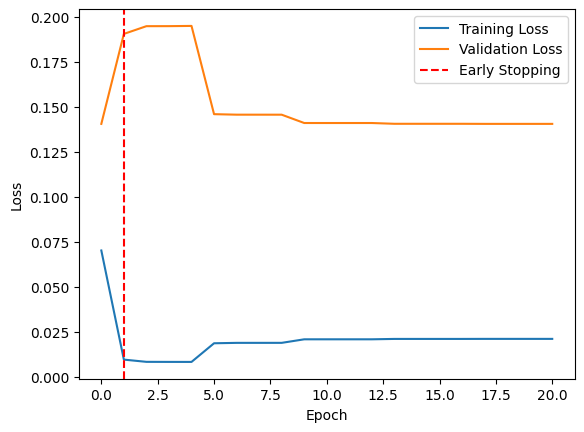

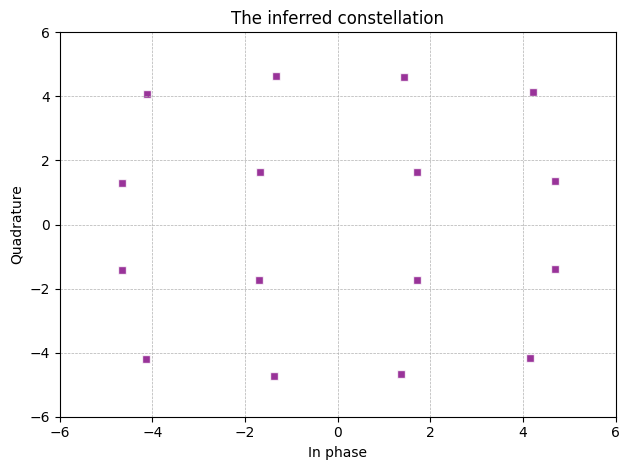

In [90]:
# @title
## Plot the cyclic learning rate schedule
#plt.plot(lrs)
#plt.xlabel("Iteration")
#plt.ylabel("Learning Rate")
#plt.title("CyclicLR - Triangular Mode")
#plt.show()

# # Plot the training loss and validation accuracy
# fig, ax1 = plt.subplots()
# ax1.set_xlabel("Epoch")
# ax1.set_ylabel("Loss", color='brown')
# ax1.plot(np.arange(1,n_epochs+1), train_loss, c='brown')
# ax1.tick_params(axis='y', labelcolor='brown',)
# ax1.set_ylim(0, 1)
# ax1.set_yticks(np.arange(0,1.2,0.2))
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
# ax2.set_ylabel('Accuracy', color='royalblue')
# ax2.plot(np.arange(1,n_epochs+1), validation_acc, c='royalblue')
# ax2.tick_params(axis='y', labelcolor='royalblue')
# ax2.set_ylim(ax1.get_ylim())
# ax2.set_yticks(np.arange(0,1.2,0.2))
# fig.tight_layout()  # otherwise the right y-label is slightly clipped
# plt.show()

# Final loss plots for analysis
import matplotlib.pyplot as plt
plt.plot(train_loss, label="Training Loss")
plt.plot(valid_loss, label="Validation Loss")
plt.axvline(x=len(valid_loss)-early_stopping.no_improvement_count, color='r',
            linestyle='--', label="Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# The model weights correspond to the inferred constellation
I = model.linear.weight.cpu().detach().numpy()[:,0]
Q = model.linear.weight.cpu().detach().numpy()[:,1]

# Plot the inferred constellation
plt.figure()
plt.scatter(I, Q, c='purple', label='Weights', marker='s', alpha=0.8,
            edgecolor='white')
ax_lim = np.ceil(1.1*np.max([I, Q]))
plt.ylim(-ax_lim, ax_lim)
plt.xlim(-ax_lim, ax_lim)
plt.title('The inferred constellation')
plt.xlabel('In phase')
plt.ylabel('Quadrature')
#plt.legend(loc="center")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()



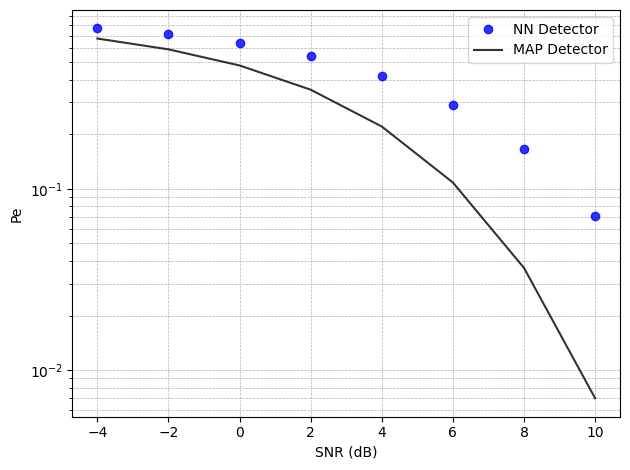

In [91]:
# ---------- Final evaluation ----------
acc_final, SER_theory = [], []
for j,snr_db in enumerate(snr_db_test):

  test_x = awgn_iq(symbols_iq[n_train:], snr_db)  # re-noise test partition (fresh noise)
  test_y = symbols[n_train:]

  # Convert to PyTorch tensors
  test_x_t = torch.from_numpy(test_x).float()
  test_y_t = torch.from_numpy(test_y).float().long()

  model.eval()
  with torch.no_grad():
      xb = test_x_t.to(device)
      yb = test_y_t.to(device)
      probs = model(xb)
      preds = probs.argmax(dim=1)
      acc_final.append((preds == yb).float().mean().item())
  #print(f"Final test accuracy: {acc_final[-1]*100:.2f}%")
  SER_theory.append(ser_awgn(snr_db,mod_type,M))
## Show some example predictions (first 10)
#examples = 10
#with torch.no_grad():
#    ex_x = xb[:examples].cpu().numpy()
#    ex_y = yb[:examples].cpu().numpy().flatten()
#    ex_p = probs[:examples].cpu().numpy().flatten()
#    ex_pred = preds[:examples].cpu().numpy().flatten()
#
#print("\nExample (I, Q) | true_bit -> prob -> pred_bit")
#for i in range(examples):
#    i_val, q_val = ex_x[i]
#    print(f"({i_val: .3f}, {q_val: .3f}) | {int(ex_y[i])} -> {ex_p[i]:.3f} -> {int(ex_pred[i])}")

# Plot the probability of symbol error
fig, ax = plt.subplots()
ax.semilogy(snr_db_test, 1-np.array(acc_final), 'o', c='blue',alpha=0.8,
           label='NN Detector')
ax.semilogy(snr_db_test, np.array(SER_theory), c='black',alpha=0.8,
           label='MAP Detector')
plt.xlabel('SNR (dB)')
plt.ylabel('Pe')
plt.legend(loc="upper right")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
